# Day 1-2: 문제 이해 & 베이스라인 모델

**강의 시간**: 1.5시간  
**학습 목표**:
- 뉴스 토픽 분류 문제의 특성 이해
- 데이터 탐색(EDA)을 통한 인사이트 도출
- TF-IDF + Logistic Regression 베이스라인 구축
- MLflow로 첫 실전 실험 기록

**사전 요구사항**: Day 1-1 환경 설정 완료


## 🔧 0. 환경 재설정


새 노트북을 시작하므로 필요한 설정을 다시 로드합니다.

In [ ]:
# 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings

warnings.filterwarnings('ignore')

# 1) 폰트 파일 직접 다운로드 (런타임 재시작 불필요)
!wget -q -O NanumGothic.ttf -L "https://fonts.gstatic.com/ea/nanumgothic/v5/NanumGothic-Regular.ttf"

import matplotlib.font_manager as fm

# 폰트 파일 경로
font_path = "NanumGothic.ttf"

# 폰트 매니저에 폰트 추가
fm.fontManager.addfont(font_path)

# 폰트 속성 설정
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["axes.unicode_minus"] = False

# Seaborn 스타일
sns.set_style('whitegrid')

print("✅ 라이브러리 로드 완료!")

✅ 라이브러리 로드 완료!


In [ ]:
fe = fm.FontEntry(fname=r'/usr/share/fonts/truetype/nanum/NanumGothic.ttf', name='NanumGothic') # 파일 저장되어있는 경로와 이름 설정
fm.fontManager.ttflist.insert(0, fe)  # Matplotlib에 폰트 추가
plt.rcParams.update({'font.size': 10, 'font.family': 'NanumGothic'}) #폰트설정

In [ ]:
# 라이브러리 설치 (약 30초 소요)
%pip install -q dagshub 'mlflow>=2,<3'

print("✅ 라이브러리 설치 완료!")

✅ 라이브러리 설치 완료!


In [ ]:
# Dagshub & MLflow 재연동
import dagshub
import mlflow

# 🔥 본인의 정보로 수정!
repo_owner = 'dev.codecompose'  # 본인의 Dagshub username
repo_name = 'deeplearning-bootcamp'  # 생성한 repository 이름 (예: deeplearning-bootcamp)

dagshub.init(
    repo_owner=repo_owner,
    repo_name=repo_name,
    mlflow=True
)

mlflow.set_experiment("day1-news-classification")

print("✅ Dagshub 연동 완료!")

Accessing as dev.codecompose

Initialized MLflow to track repo "dev.codecompose/deeplearning-bootcamp"

Repository dev.codecompose/deeplearning-bootcamp initialized!

✅ Dagshub 연동 완료!



## 📂 1. 데이터 로드



### 데이터 불러오기

#### Google Drive

In [ ]:
# from google.colab import drive

# # Google Drive 마운트
# drive.mount('/content/drive')

# print("\n✅ Google Drive 연결 완료!")
# print("📁 Drive 경로: /content/drive/MyDrive")

In [ ]:
# import shutil
# import os

# # Google Drive에서 복사 (Drive에 업로드했을 경우)
# # drive_data_path = '/content/drive/MyDrive/dacon_data'  # Drive에 업로드한 경로
# drive_data_path = '/content/drive/MyDrive/lectures/dl_bootcamp/day1_news_classification/data/dacon_data'  # Drive에 업로드한 경로

# # 현재 작업 폴더로 복사
# if os.path.exists(f'{drive_data_path}/train_data.csv'):
#     shutil.copy(f'{drive_data_path}/train_data.csv', './train_data.csv')
#     shutil.copy(f'{drive_data_path}/test_data.csv', './test_data.csv')
#     shutil.copy(f'{drive_data_path}/topic_dict.csv', './topic_dict.csv')
#     shutil.copy(f'{drive_data_path}/sample_submission.csv', './sample_submission.csv')
#     print("✅ Drive에서 데이터 복사 완료!")
# else:
#     print("❌ Drive에 데이터가 없습니다. 방법 1을 사용하세요.")

#### 데이터 업로드

In [ ]:
import os
import zipfile
from google.colab import files

# 1. 경로 설정
# 최종적으로 데이터가 저장될 하위 폴더 이름은 'dacon_data'로 고정합니다.
base_data_path = '/content/data'
target_path = os.path.join(base_data_path, 'dacon_data')

os.makedirs(target_path, exist_ok=True)

# 2. 파일 업로드
print("📤 업로드할 ZIP 파일을 선택해주세요 (파일명 상관없음)...")
uploaded = files.upload()

# 3. 업로드된 파일 중 ZIP 파일 자동 탐색 및 압축 해제
uploaded_zip_files = [f for f in uploaded.keys() if f.endswith('.zip')]

if uploaded_zip_files:
    # 가장 먼저 업로드된 ZIP 파일 하나를 대상으로 수행
    zip_file_name = uploaded_zip_files[0]

    print(f"\n📦 '{zip_file_name}'을(를) {target_path}에 압축 해제 중...")
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall(target_path)

    print(f"✅ 압축 해제 완료: {target_path}")

    # 세션 용량 확보를 위해 업로드된 원본 zip 파일 삭제
    os.remove(zip_file_name)
else:
    print("\n⚠️ 업로드된 파일 중 ZIP 형식이 없습니다.")

# 4. 결과 확인
print(f"\n📂 {target_path} 내부 파일 목록:")
try:
    print(os.listdir(target_path))
except FileNotFoundError:
    print("폴더가 생성되지 않았습니다.")

📤 업로드할 ZIP 파일을 선택해주세요 (파일명 상관없음)...


Saving open (2).zip to open (2) (1).zip

📦 'open (2) (1).zip'을(를) /content/data/dacon_data에 압축 해제 중...
✅ 압축 해제 완료: /content/data/dacon_data

📂 /content/data/dacon_data 내부 파일 목록:
['sample_submission.csv', 'test_data.csv', 'topic_dict.csv', 'train_data.csv']


In [ ]:
data_path = target_path

#### 데이터 불러오기

In [ ]:
# CSV 파일 로드
train_df = pd.read_csv(os.path.join(data_path, 'train_data.csv'))
test_df = pd.read_csv(os.path.join(data_path, 'test_data.csv'))

print(f"✅ Train 데이터: {len(train_df):,}개")
print(f"✅ Test 데이터: {len(test_df):,}개")

# 처음 5개 샘플 확인
train_df.head()

✅ Train 데이터: 45,654개
✅ Test 데이터: 9,131개


,index,title,topic_idx
0,0,인천→핀란드 항공기 결항…휴가철 여행객 분통,4
1,1,실리콘밸리 넘어서겠다…구글 15조원 들여 美전역 거점화,4
2,2,이란 외무 긴장완화 해결책은 미국이 경제전쟁 멈추는 것,4
3,3,NYT 클린턴 측근韓기업 특수관계 조명…공과 사 맞물려종합,4
4,4,시진핑 트럼프에 중미 무역협상 조속 타결 희망,4


### 데이터 구조 확인

In [ ]:
# 데이터 정보
print("📊 데이터 정보:")
print(train_df.info())

print("\n📊 기본 통계:")
print(train_df.describe())

📊 데이터 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45654 entries, 0 to 45653
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   index      45654 non-null  int64 
 1   title      45654 non-null  object
 2   topic_idx  45654 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.0+ MB
None

📊 기본 통계:
              index     topic_idx
count  45654.000000  45654.000000
mean   22826.500000      3.163622
std    13179.318932      1.932897
min        0.000000      0.000000
25%    11413.250000      2.000000
50%    22826.500000      3.000000
75%    34239.750000      5.000000
max    45653.000000      6.000000


In [ ]:
# 컬럼 확인
print("📋 Train 컬럼:", train_df.columns.tolist())
print("📋 Test 컬럼:", test_df.columns.tolist())

# 결측치 확인
print("\n❓ Train 결측치:")
print(train_df.isnull().sum())

print("\n❓ Test 결측치:")
print(test_df.isnull().sum())

📋 Train 컬럼: ['index', 'title', 'topic_idx']
📋 Test 컬럼: ['index', 'title']

❓ Train 결측치:
index        0
title        0
topic_idx    0
dtype: int64

❓ Test 결측치:
index    0
title    0
dtype: int64



## 📊 2. 탐색적 데이터 분석 (EDA)

### 2.1 타겟(토픽) 분포 확인

In [ ]:
# 토픽별 개수
topic_counts = train_df['topic_idx'].value_counts().sort_index()

print("📊 토픽별 분포:")
print(topic_counts)

# 토픽 이름 매핑 (실제 데이터에 맞게 수정 필요)
topic_names = {
    0: '정치',
    1: '경제',
    2: '사회',
    3: '생활/문화',
    4: '세계',
    5: 'IT/과학',
    6: '스포츠'
}

print("\n📌 토픽 이름:")
for idx, name in topic_names.items():
    count = topic_counts.get(idx, 0)
    print(f"  {idx}: {name} - {count:,}개 ({count/len(train_df)*100:.1f}%)")

📊 토픽별 분포:
topic_idx
0    4824
1    6222
2    7362
3    5933
4    7629
5    6933
6    6751
Name: count, dtype: int64

📌 토픽 이름:
  0: 정치 - 4,824개 (10.6%)
  1: 경제 - 6,222개 (13.6%)
  2: 사회 - 7,362개 (16.1%)
  3: 생활/문화 - 5,933개 (13.0%)
  4: 세계 - 7,629개 (16.7%)
  5: IT/과학 - 6,933개 (15.2%)
  6: 스포츠 - 6,751개 (14.8%)


In [ ]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

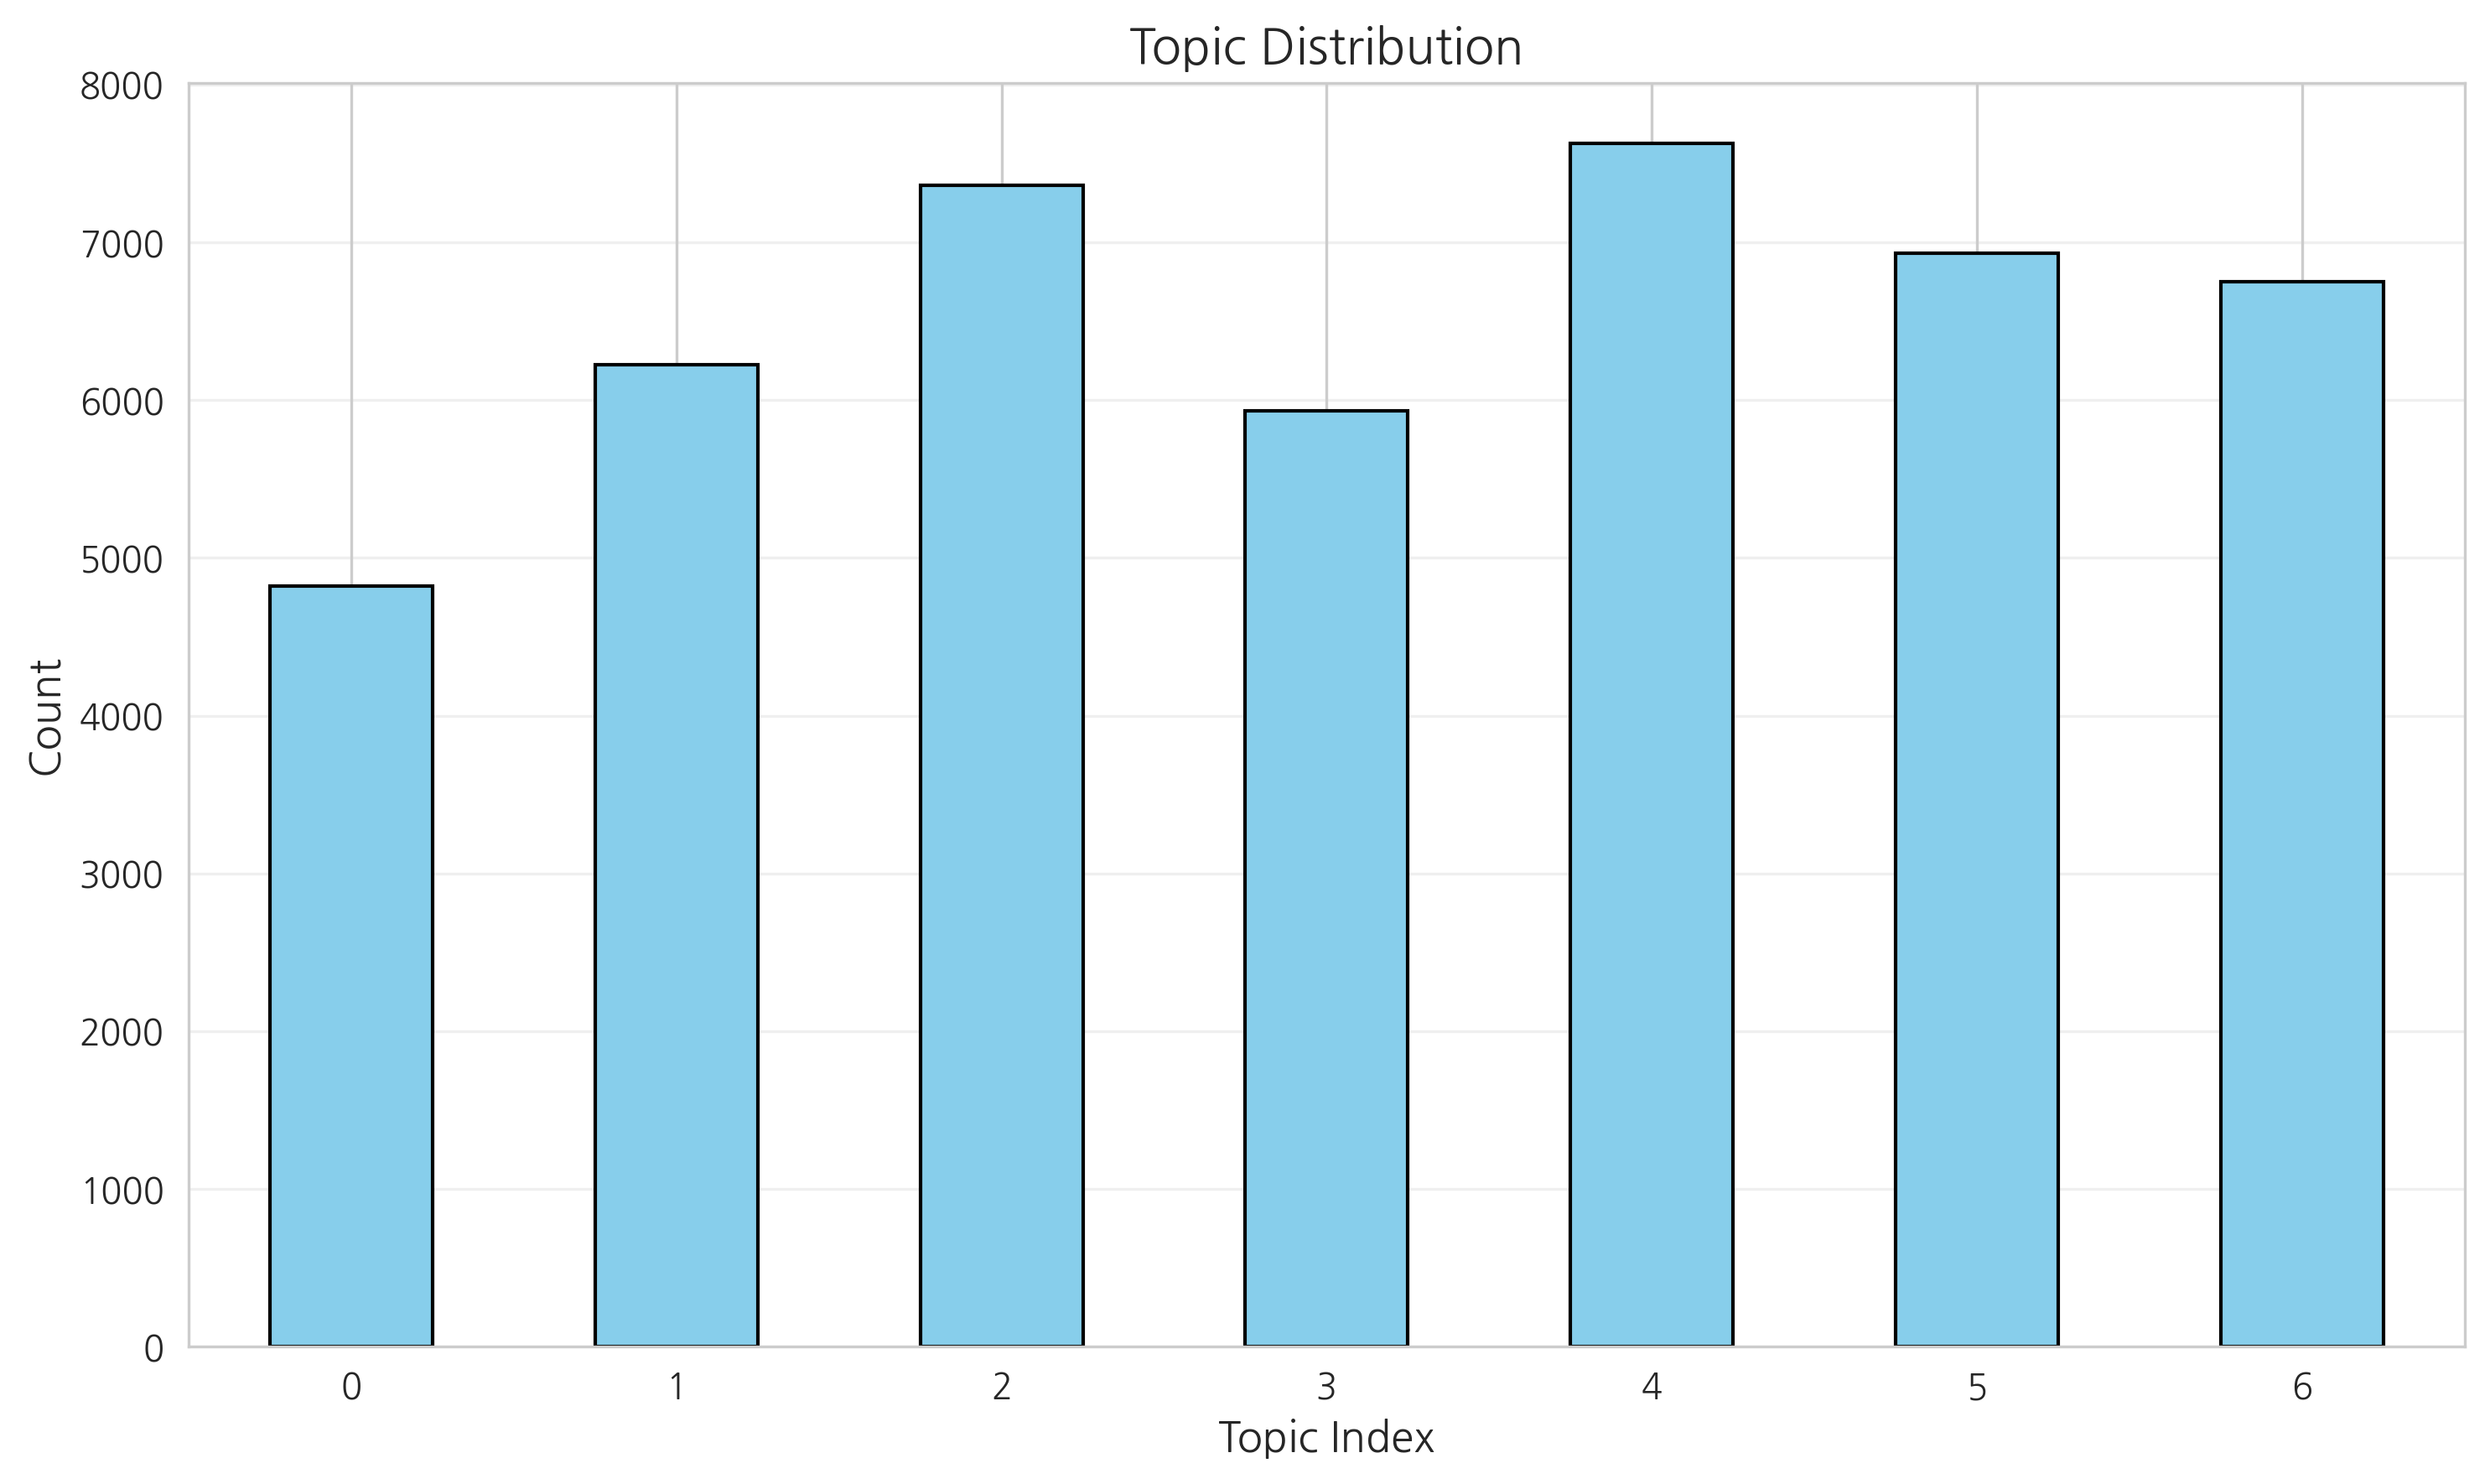

In [ ]:
# 시각화
plt.figure(figsize=(10, 6))
topic_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Topic Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Topic Index', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ❓ 질문: 데이터가 불균형한가요? 가장 많은 토픽과 가장 적은 토픽의 비율은?

### 2.2 텍스트 길이 분석

In [ ]:
# 헤드라인 길이 계산
train_df['title_length'] = train_df['title'].str.len()

print("📏 헤드라인 길이 통계:")
print(train_df['title_length'].describe())

# 토픽별 평균 길이
print("\n📏 토픽별 평균 길이:")
avg_length_by_topic = train_df.groupby('topic_idx')['title_length'].mean().sort_values(ascending=False)
print(avg_length_by_topic)

📏 헤드라인 길이 통계:
count    45654.000000
mean        27.330552
std          4.968172
min          4.000000
25%         25.000000
50%         28.000000
75%         31.000000
max         44.000000
Name: title_length, dtype: float64

📏 토픽별 평균 길이:
topic_idx
4    28.960939
5    28.785951
0    27.511816
1    27.325940
6    27.112132
2    26.458571
3    24.721389
Name: title_length, dtype: float64


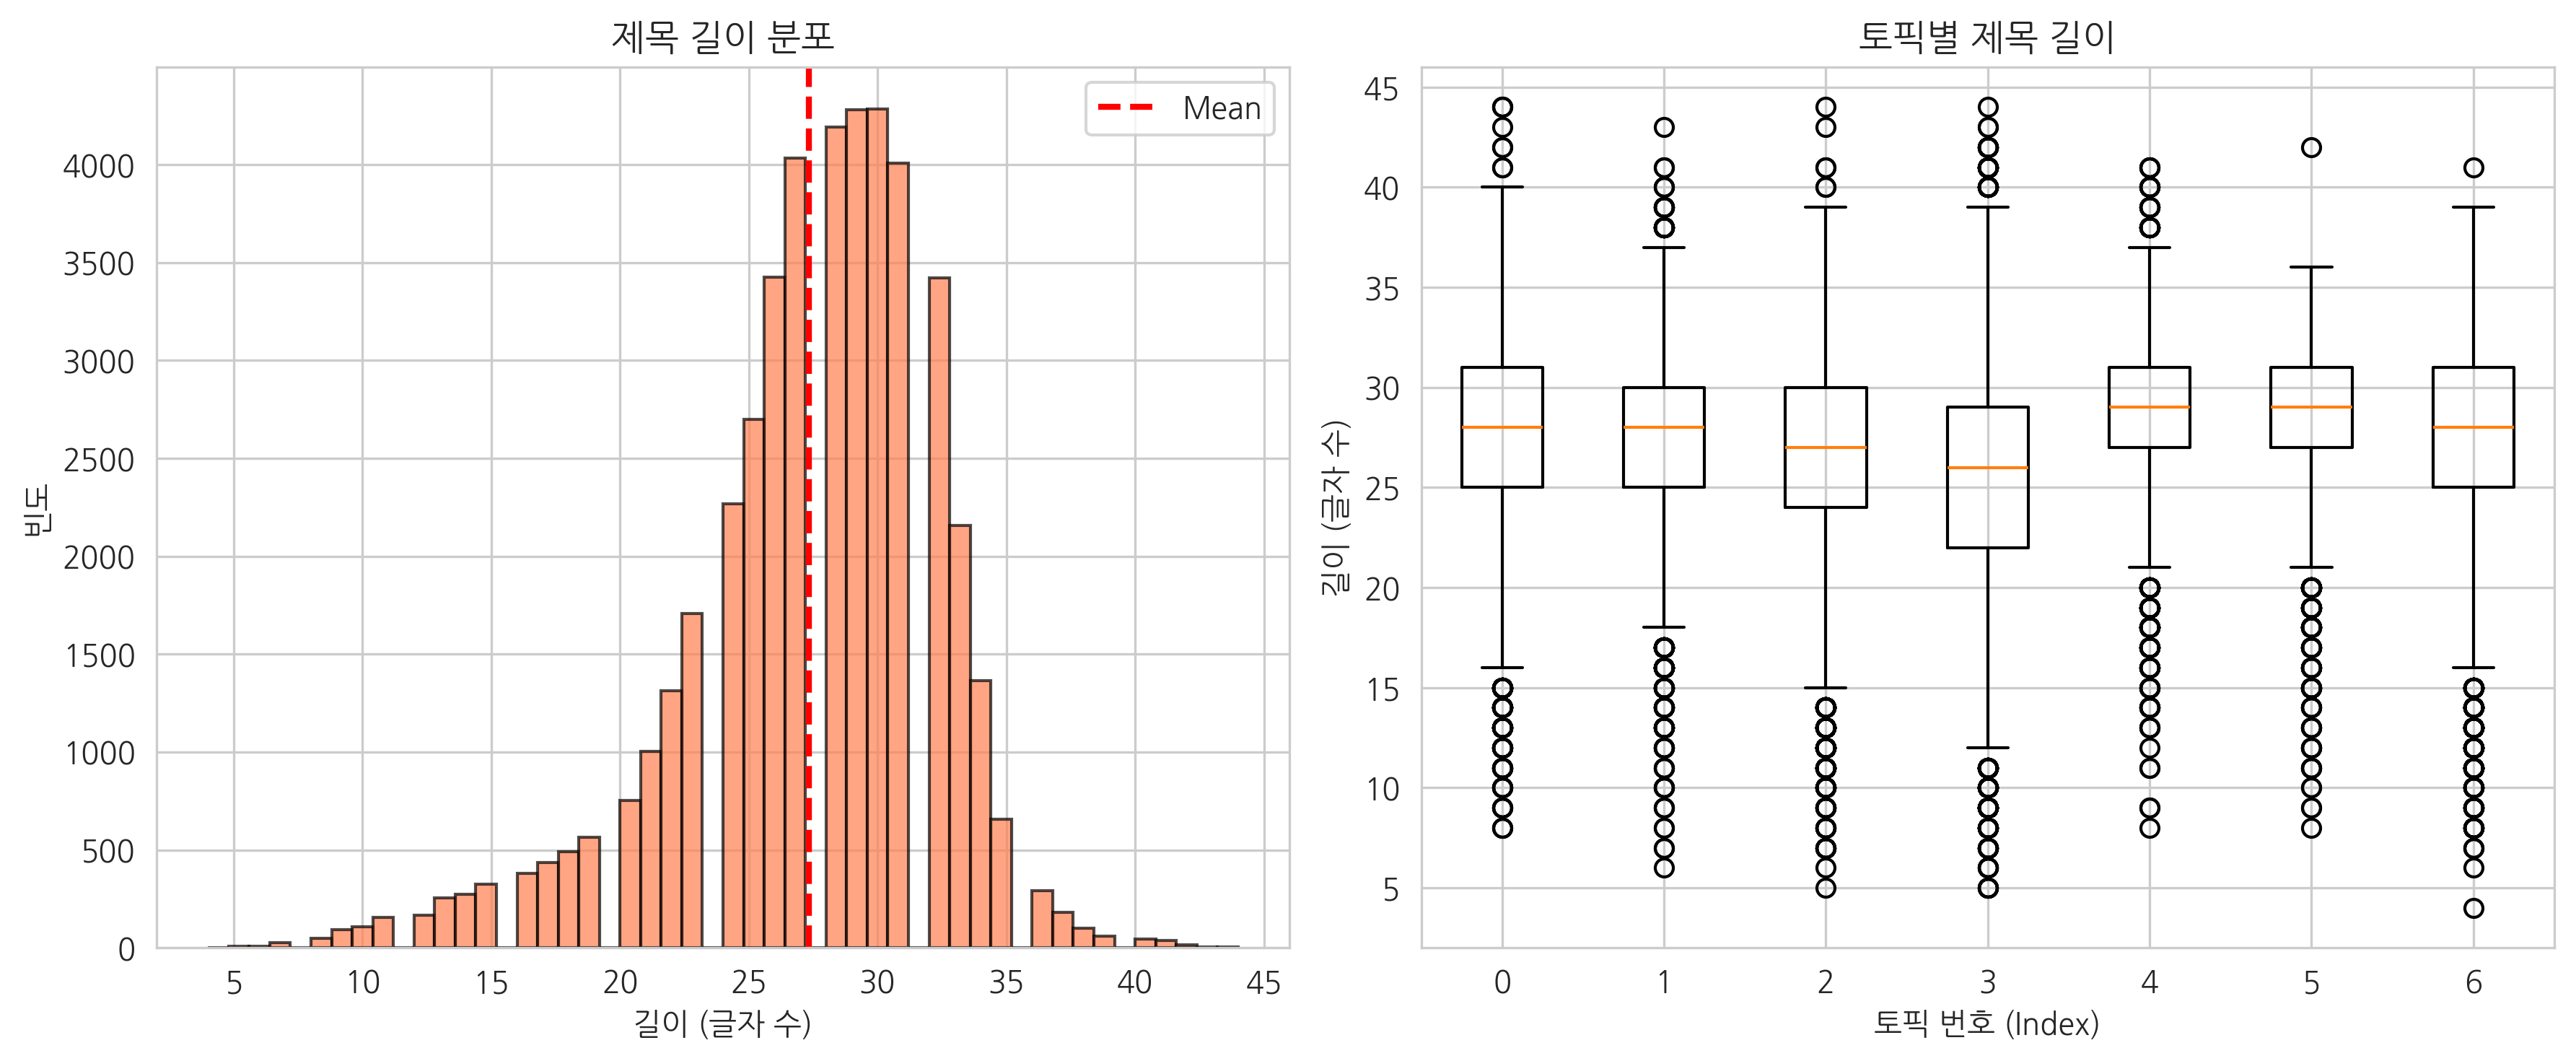

In [ ]:
# 길이 분포 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(train_df['title_length'], bins=50, color='coral', edgecolor='black', alpha=0.7)
plt.axvline(train_df['title_length'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
plt.title('제목 길이 분포', fontweight='bold')
plt.xlabel('길이 (글자 수)')
plt.ylabel('빈도')
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot([train_df[train_df['topic_idx']==i]['title_length'] for i in range(7)],
            labels=range(7))
plt.title('토픽별 제목 길이', fontweight='bold')
plt.xlabel('토픽 번호 (Index)')
plt.ylabel('길이 (글자 수)')

plt.tight_layout()
plt.show()

### 2.3 샘플 데이터 확인

In [ ]:
# 각 토픽별로 3개씩 샘플 확인
print("📰 각 토픽별 샘플 헤드라인:\n")

for topic_idx in range(7):
    topic_name = topic_names.get(topic_idx, f'Unknown-{topic_idx}')
    samples = train_df[train_df['topic_idx'] == topic_idx]['title'].sample(min(3, len(train_df[train_df['topic_idx'] == topic_idx]))).values

    print(f"\n🔹 {topic_idx}: {topic_name}")
    for i, sample in enumerate(samples, 1):
        print(f"  {i}. {sample}")

📰 각 토픽별 샘플 헤드라인:


🔹 0: 정치
  1. 과천과학관에 연내 국방체험관 조성…과천과학관·방사청 협약
  2. 갤럭시S8 시리즈 글로벌 판매량 500만대 돌파종합
  3. LG유플러스 공식 온라인몰서 아이폰6 0원에 판매

🔹 1: 경제
  1. 11월 단기성 영국 자금 2.2조 국내 주식 매입…치고 빠지기
  2. 원달러 환율 주문실수에 개장가 혼란…1227.0원 정정 개장종합2보
  3. 케이옥션 3월 경매 낙찰률 71%·낙찰총액 86억원 기록

🔹 2: 사회
  1. 전교조 무력화한 법외노조 통보 제도 무효…대폭 손질 불가피
  2. 대전·세종·충남교육청 공립 중등교사 임용시험 사전 예고
  3. 오전 문제가 오후에 그대로…경찰 외국어요원 채용시험 뒷말종합

🔹 3: 생활/문화
  1. 연극 앙리할아버지와 나 15일 개막…캐릭터 포스터 공개
  2. 영하 14도… 꽁꽁 언 얼음
  3. 보고 들으며 즐기는 詩…찾아가는 시문학 공연

🔹 4: 세계
  1. 펜스 EU가 이란 제재 깨려해 직격…폴란드서 이란 놓고 신경전
  2. 그리스 문화유적 보호에 제동 걸린 중 일대일로
  3. 이스라엘 총선 킹메이커는 대마초 합법화

🔹 5: IT/과학
  1. 여자 3대3 농구 국제대회 1314일 고양에서 개최
  2. 살아난 김종규 18득점…프로농구 LG kt 꺾고 6연패 탈출
  3. 프로농구 6강 플레이오프의 공통 화두…1차전을 잡아라

🔹 6: 스포츠
  1. 천정배 총선홍보비 파동에 잘못있으면 단호히 책임 물을 것
  2. 민주 공수처 설치 연일 한국당 압박…정치적 꼼수 그만
  3. 野 우병우 의혹·與 자중지란에 정권 말기현상 총공세



## 🤖 3. 베이스라인 모델: TF-IDF + Logistic Regression



### 3.1 데이터 준비

In [ ]:
from sklearn.model_selection import train_test_split

# Train / Validation 분리
X = train_df['title']
y = train_df['topic_idx']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,  # 20%를 검증용으로
    random_state=42,
    stratify=y  # 각 클래스 비율 유지
)

print(f"✅ Train: {len(X_train):,}개")
print(f"✅ Validation: {len(X_val):,}개")

# 검증 세트의 토픽 분포 확인
print("\n📊 Validation 토픽 분포:")
print(y_val.value_counts().sort_index())

✅ Train: 36,523개
✅ Validation: 9,131개

📊 Validation 토픽 분포:
topic_idx
0     965
1    1244
2    1472
3    1187
4    1526
5    1387
6    1350
Name: count, dtype: int64


### 3.2 TF-IDF Vectorization


💡 **TF-IDF란?**
- **TF (Term Frequency)**: 문서 내 단어 빈도
- **IDF (Inverse Document Frequency)**: 전체 문서에서 희귀한 정도
- 중요한 단어에 높은 가중치 부여

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF 변환기 생성
tfidf = TfidfVectorizer(
    max_features=5000,  # 상위 5000개 단어만 사용
    ngram_range=(1, 1),  # unigram만 (단어 1개씩)
    min_df=2,  # 최소 2개 문서에 나타나야 함
    max_df=0.9,  # 90% 이상 문서에 나타나면 제외 (불용어)
    analyzer='char',  # 한글: 문자(char) 단위가 효과적
    sublinear_tf=True  # TF에 log 스케일 적용
)

# Train 데이터로 fit & transform
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)  # Validation은 transform만!

print(f"✅ TF-IDF 변환 완료!")
print(f"📊 Feature 개수: {X_train_tfidf.shape[1]:,}")
print(f"📊 Train shape: {X_train_tfidf.shape}")
print(f"📊 Val shape: {X_val_tfidf.shape}")

✅ TF-IDF 변환 완료!
📊 Feature 개수: 1,514
📊 Train shape: (36523, 1514)
📊 Val shape: (9131, 1514)


### 3.3 Logistic Regression 학습

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# 모델 생성
model = LogisticRegression(
    C=1.0,  # Regularization 강도 (작을수록 강함)
    max_iter=1000,  # 최대 반복 횟수
    random_state=42,
    n_jobs=-1  # 모든 CPU 코어 사용
)

print("🏋️ 모델 학습 시작...")
model.fit(X_train_tfidf, y_train)
print("✅ 학습 완료!")

🏋️ 모델 학습 시작...
✅ 학습 완료!


### 3.4 예측 및 평가

In [ ]:
# 예측
y_train_pred = model.predict(X_train_tfidf)
y_val_pred = model.predict(X_val_tfidf)

# 평가 지표 계산
train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)

train_f1 = f1_score(y_train, y_train_pred, average='macro')
val_f1 = f1_score(y_val, y_val_pred, average='macro')

print("📊 모델 성능:")
print(f"\n  Train Accuracy: {train_acc:.4f}")
print(f"  Train F1 (Macro): {train_f1:.4f}")
print(f"\n  Val Accuracy: {val_acc:.4f}")
print(f"  Val F1 (Macro): {val_f1:.4f}")

# 목표 달성 여부
if val_f1 >= 0.80:
    print("\n🎉 목표 달성! (F1 >= 0.80)")
else:
    print(f"\n⚠️ 목표 미달성 (현재: {val_f1:.4f}, 목표: 0.80)")

📊 모델 성능:

  Train Accuracy: 0.7888
  Train F1 (Macro): 0.7873

  Val Accuracy: 0.7574
  Val F1 (Macro): 0.7556

⚠️ 목표 미달성 (현재: 0.7556, 목표: 0.80)


### 3.5 상세 분류 리포트

In [ ]:
# 클래스별 성능
print("📋 Classification Report (Validation):")
print(classification_report(y_val, y_val_pred, target_names=[topic_names[i] for i in range(7)]))

📋 Classification Report (Validation):
              precision    recall  f1-score   support

          정치       0.72      0.71      0.72       965
          경제       0.75      0.73      0.74      1244
          사회       0.63      0.62      0.63      1472
       생활/문화       0.72      0.75      0.74      1187
          세계       0.81      0.78      0.80      1526
       IT/과학       0.84      0.87      0.85      1387
         스포츠       0.81      0.81      0.81      1350

    accuracy                           0.76      9131
   macro avg       0.76      0.76      0.76      9131
weighted avg       0.76      0.76      0.76      9131



### 3.6 Confusion Matrix 시각화

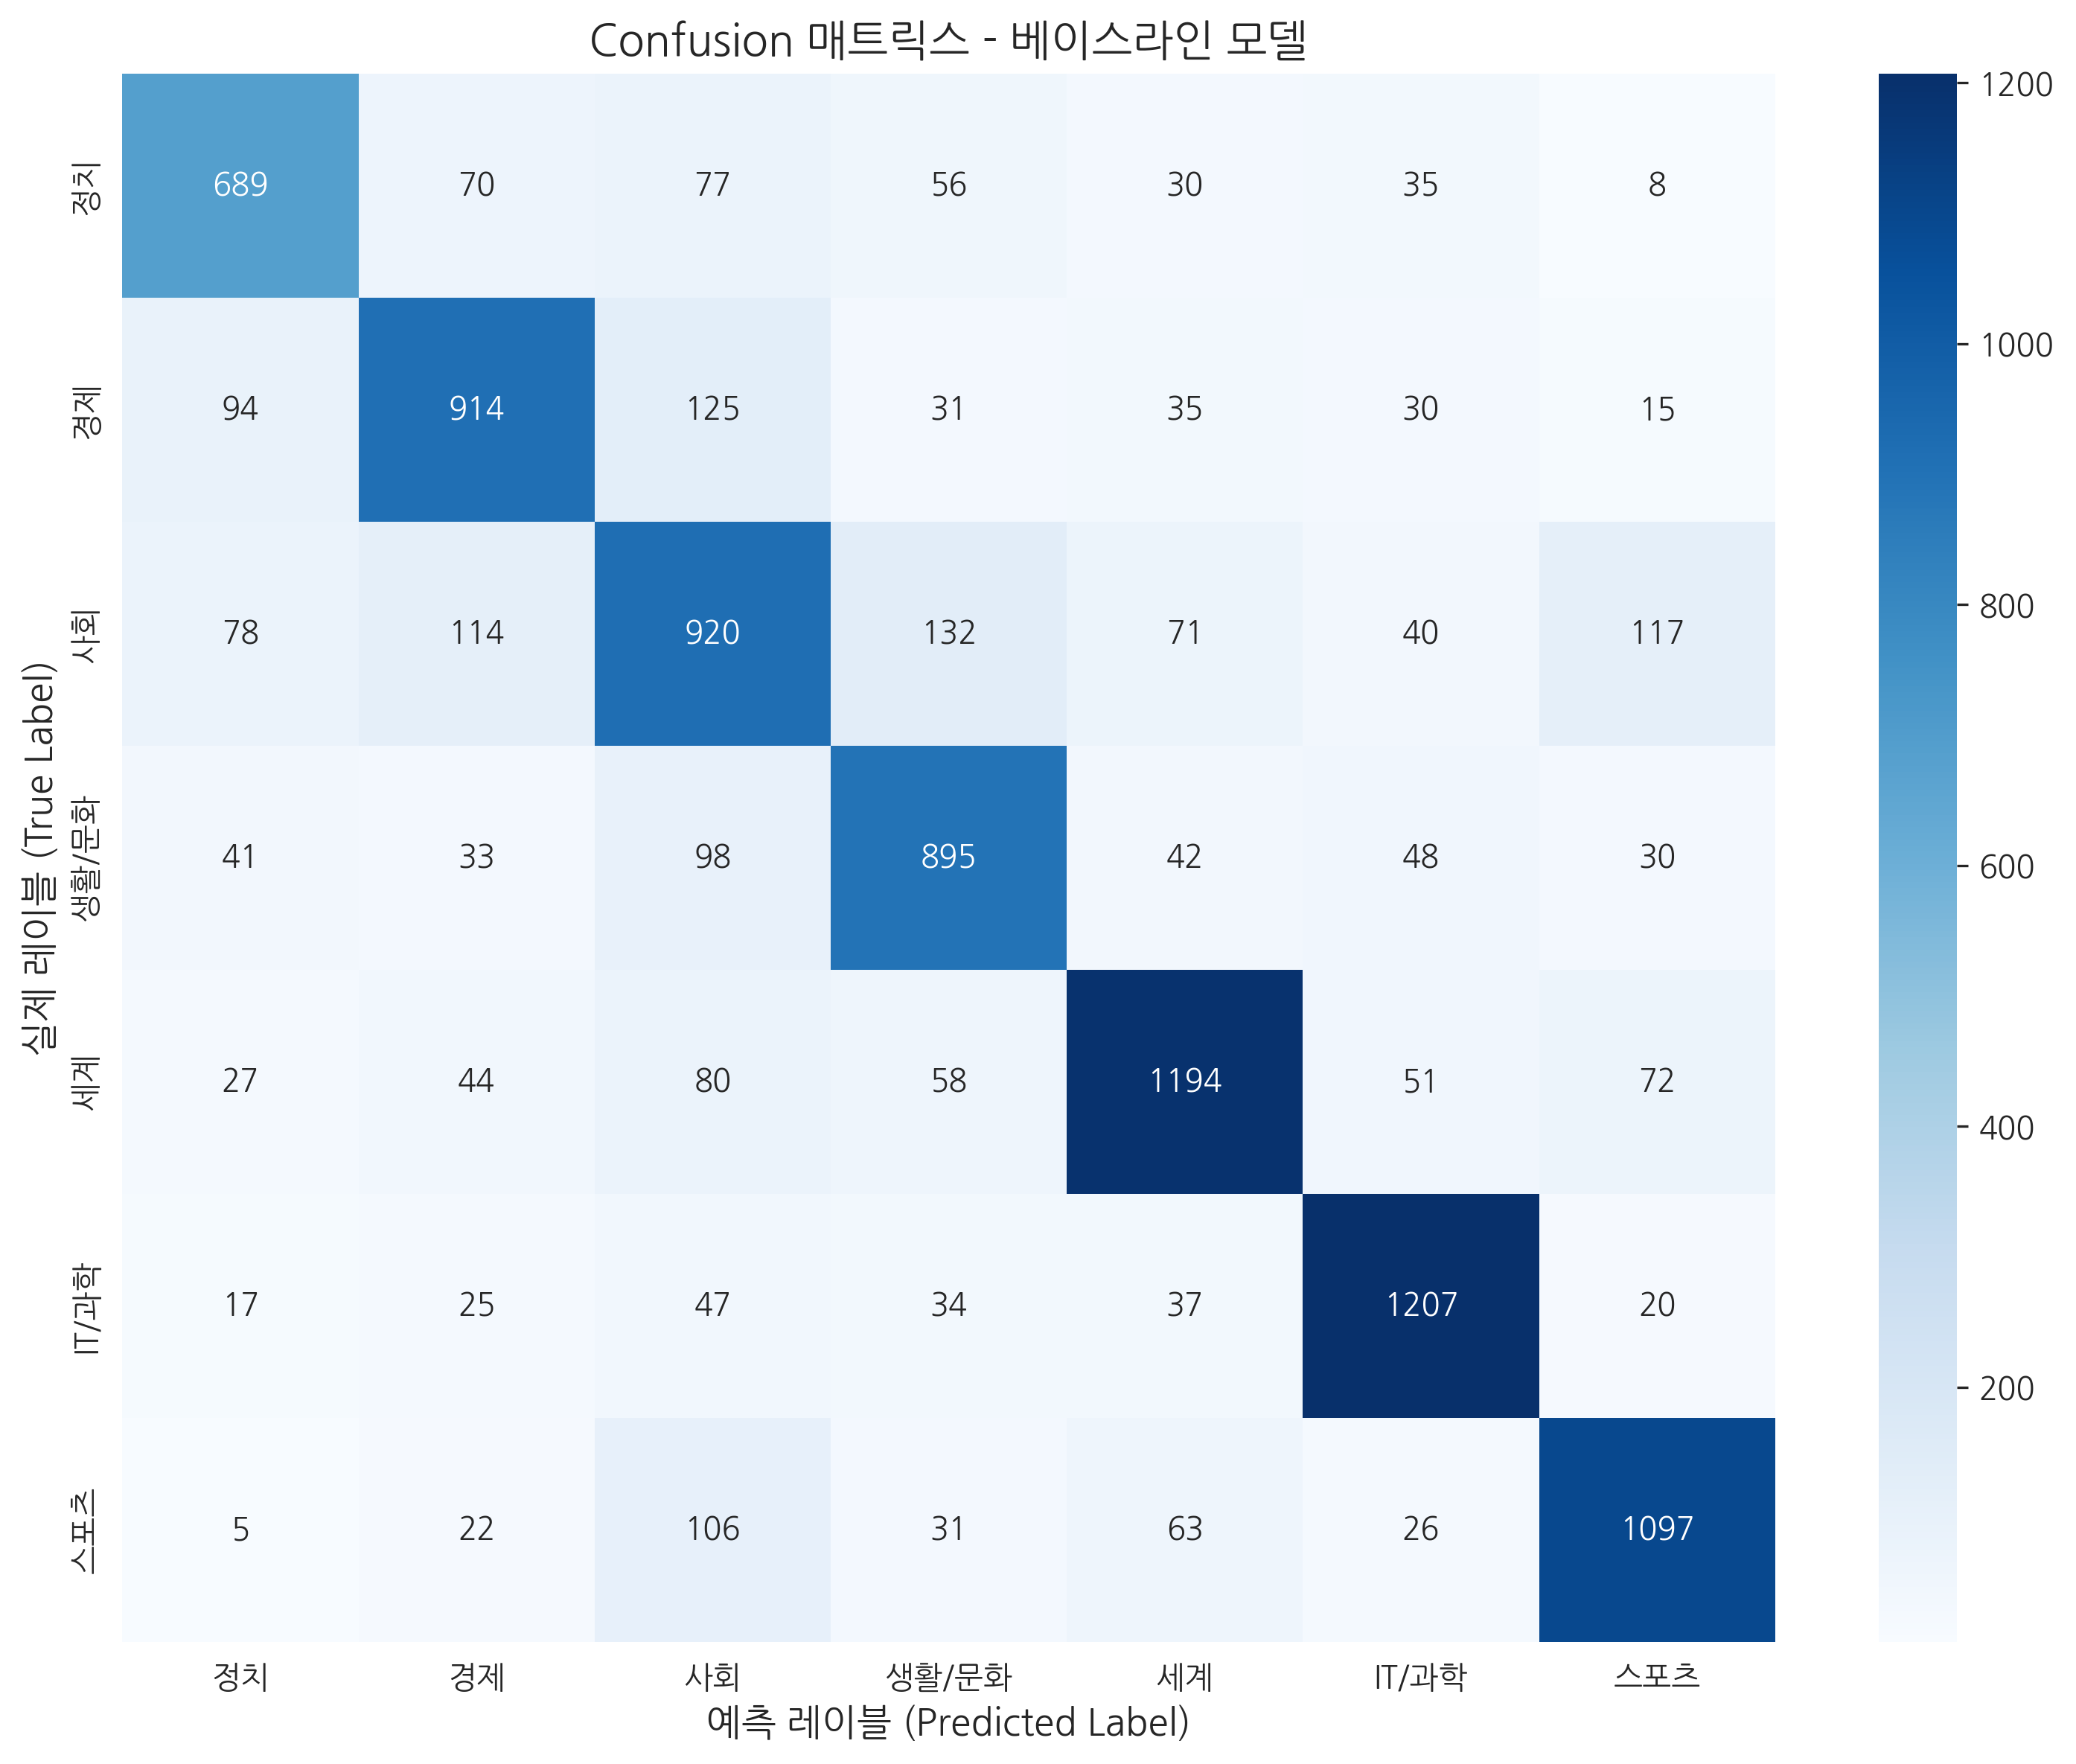

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[topic_names[i] for i in range(7)],
            yticklabels=[topic_names[i] for i in range(7)])
plt.title('Confusion 매트릭스 - 베이스라인 모델', fontsize=14, fontweight='bold')
plt.ylabel('실제 레이블 (True Label)', fontsize=12)
plt.xlabel('예측 레이블 (Predicted Label)', fontsize=12)
plt.tight_layout()

# 이미지 저장 (MLflow에 업로드할 예정)
plt.savefig('confusion_matrix_baseline.png', dpi=100, bbox_inches='tight')
plt.show()

# ❓ 질문: 어떤 토픽끼리 자주 혼동되나요?


## 🔬 4. MLflow 실험 로깅



### 4.1 첫 번째 실전 실험 기록

In [ ]:
# MLflow에 실험 기록
with mlflow.start_run(run_name="baseline-tfidf-C1.0-maxfeat5000"):

    # ===== Parameters (하이퍼파라미터) =====
    mlflow.log_param('model_type', 'TF-IDF + LogisticRegression')
    mlflow.log_param('max_features', 5000)
    mlflow.log_param('ngram_range', '(1,1)')
    mlflow.log_param('C', 1.0)
    mlflow.log_param('analyzer', 'char')
    mlflow.log_param('test_size', 0.2)

    # ===== Metrics (평가 지표) =====
    mlflow.log_metric('train_accuracy', train_acc)
    mlflow.log_metric('train_f1_macro', train_f1)
    mlflow.log_metric('val_accuracy', val_acc)
    mlflow.log_metric('val_f1_macro', val_f1)

    # ===== Artifacts (산출물) =====
    mlflow.log_artifact('confusion_matrix_baseline.png')

    # Classification report를 텍스트로 저장
    with open('classification_report.txt', 'w') as f:
        f.write(classification_report(y_val, y_val_pred,
                                     target_names=[topic_names[i] for i in range(7)]))
    mlflow.log_artifact('classification_report.txt')

    print("✅ MLflow 실험 기록 완료!")
    print(f"🔍 Dagshub: https://dagshub.com/YOUR_USERNAME/YOUR_REPO_NAME/experiments")

✅ MLflow 실험 기록 완료!
🔍 Dagshub: https://dagshub.com/YOUR_USERNAME/YOUR_REPO_NAME/experiments
🏃 View run baseline-tfidf-C1.0-maxfeat5000 at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/1/runs/3ef9ddfeb3e54fbf8fbd939c409b52c7
🧪 View experiment at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/1


### 4.2 Dagshub UI 확인




1. Dagshub 프로젝트 페이지 이동
2. "Experiments" 탭 클릭
3. `baseline-tfidf-C1.0-maxfeat5000` 실험 확인
4. Parameters, Metrics, Artifacts 확인

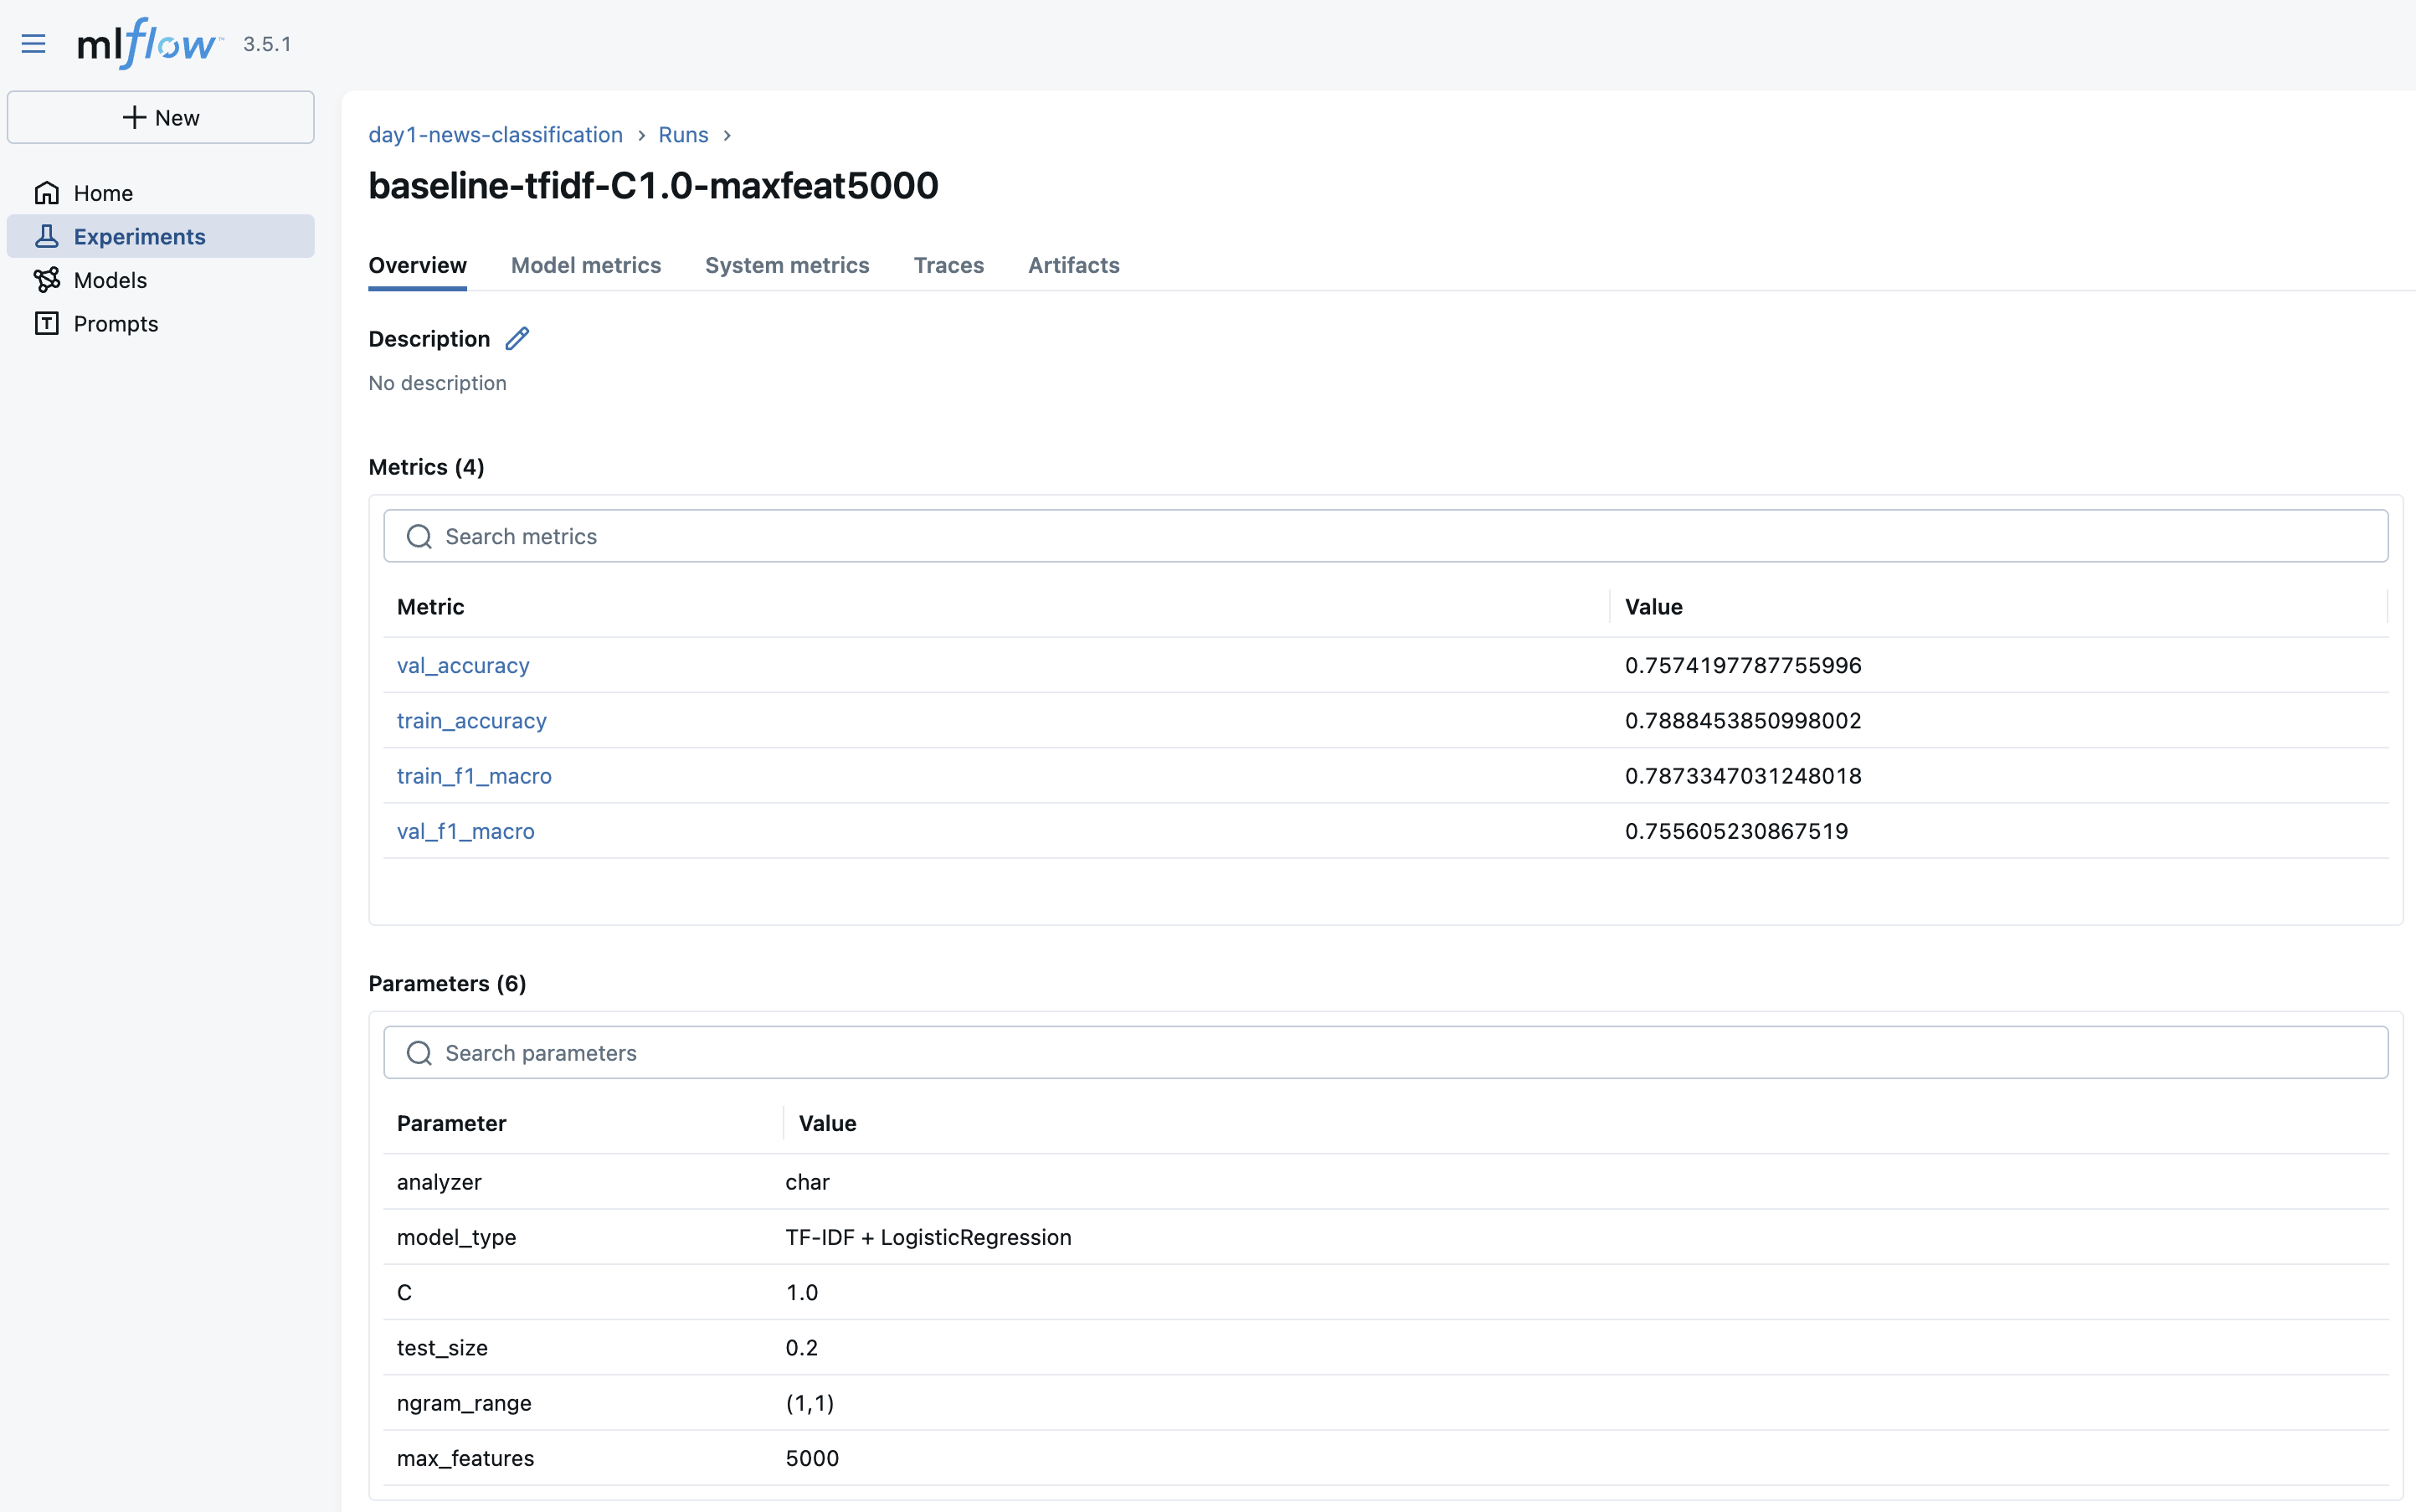

## 💡 5. 성능 개선 실험 (자유 시간)

### 실험 1: max_features 조정

In [ ]:
# 🎯 도전 과제: max_features를 바꿔서 실험해보세요!
# 힌트: 1000, 3000, 10000 등으로 변경

# TODO: 여러분이 직접 작성해보세요
# 1. TfidfVectorizer의 max_features 변경
# 2. fit_transform 재실행
# 3. 모델 학습 & 평가
# 4. MLflow 로깅 (run_name 변경!)

# 예시 코드 (주석 해제 후 수정):
# tfidf_new = TfidfVectorizer(max_features=10000, ...)
# X_train_new = tfidf_new.fit_transform(X_train)
# ...

In [ ]:
# 실험 1-1: max_features = 3000
tfidf_exp1 = TfidfVectorizer(
    max_features=3000,  # 5000 → 3000으로 축소
    ngram_range=(1, 1),
    min_df=2,
    max_df=0.9,
    analyzer='char',
    sublinear_tf=True
)

X_train_exp1 = tfidf_exp1.fit_transform(X_train)
X_val_exp1 = tfidf_exp1.transform(X_val)

model_exp1 = LogisticRegression(C=1.0, max_iter=1000, random_state=42, n_jobs=-1)
model_exp1.fit(X_train_exp1, y_train)

y_val_pred_exp1 = model_exp1.predict(X_val_exp1)
val_f1_exp1 = f1_score(y_val, y_val_pred_exp1, average='macro')
val_acc_exp1 = accuracy_score(y_val, y_val_pred_exp1)

print(f"실험 1-1 결과:")
print(f"  Val F1: {val_f1_exp1:.4f}")
print(f"  Val Accuracy: {val_acc_exp1:.4f}")

# MLflow 로깅
with mlflow.start_run(run_name="exp1-maxfeat3000-C1.0"):
    mlflow.log_param('model_type', 'TF-IDF + LogisticRegression')
    mlflow.log_param('max_features', 3000)
    mlflow.log_param('C', 1.0)
    mlflow.log_param('ngram_range', '(1,1)')

    mlflow.log_metric('val_f1_macro', val_f1_exp1)
    mlflow.log_metric('val_accuracy', val_acc_exp1)

print("✅ 실험 1-1 MLflow 로깅 완료!")

실험 1-1 결과:
  Val F1: 0.7556
  Val Accuracy: 0.7574
🏃 View run exp1-maxfeat3000-C1.0 at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/1/runs/d549c77edaa7468e82628c1d2273756b
🧪 View experiment at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/1
✅ 실험 1-1 MLflow 로깅 완료!


In [ ]:
# 실험 1-2: max_features = 10000
tfidf_exp2 = TfidfVectorizer(
    max_features=10000,  # 5000 → 10000으로 확대
    ngram_range=(1, 1),
    min_df=2,
    max_df=0.9,
    analyzer='char',
    sublinear_tf=True
)

X_train_exp2 = tfidf_exp2.fit_transform(X_train)
X_val_exp2 = tfidf_exp2.transform(X_val)

model_exp2 = LogisticRegression(C=1.0, max_iter=1000, random_state=42, n_jobs=-1)
model_exp2.fit(X_train_exp2, y_train)

y_val_pred_exp2 = model_exp2.predict(X_val_exp2)
val_f1_exp2 = f1_score(y_val, y_val_pred_exp2, average='macro')
val_acc_exp2 = accuracy_score(y_val, y_val_pred_exp2)

print(f"실험 1-2 결과:")
print(f"  Val F1: {val_f1_exp2:.4f}")
print(f"  Val Accuracy: {val_acc_exp2:.4f}")

# MLflow 로깅
with mlflow.start_run(run_name="exp1-maxfeat10000-C1.0"):
    mlflow.log_param('model_type', 'TF-IDF + LogisticRegression')
    mlflow.log_param('max_features', 10000)
    mlflow.log_param('C', 1.0)
    mlflow.log_param('ngram_range', '(1,1)')

    mlflow.log_metric('val_f1_macro', val_f1_exp2)
    mlflow.log_metric('val_accuracy', val_acc_exp2)

print("✅ 실험 1-2 MLflow 로깅 완료!")

실험 1-2 결과:
  Val F1: 0.7556
  Val Accuracy: 0.7574
🏃 View run exp1-maxfeat10000-C1.0 at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/1/runs/4e81f75d99ff47b6b7c48854eb02c545
🧪 View experiment at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/1
✅ 실험 1-2 MLflow 로깅 완료!


### 실험 2: C 값 (Regularization) 조정

In [ ]:
# 🎯 도전 과제: C 값을 바꿔서 실험해보세요!
# 힌트: 0.1, 10.0 등으로 변경
# C가 클수록 규제 약함 (복잡한 모델), 작을수록 규제 강함 (단순한 모델)

# TODO: 여러분이 직접 작성해보세요

In [ ]:
# 실험 2-1: C = 0.1 (강한 규제)
tfidf_exp3 = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 1),
    min_df=2,
    max_df=0.9,
    analyzer='char',
    sublinear_tf=True
)

X_train_exp3 = tfidf_exp3.fit_transform(X_train)
X_val_exp3 = tfidf_exp3.transform(X_val)

model_exp3 = LogisticRegression(C=0.1, max_iter=1000, random_state=42, n_jobs=-1)
model_exp3.fit(X_train_exp3, y_train)

y_val_pred_exp3 = model_exp3.predict(X_val_exp3)
val_f1_exp3 = f1_score(y_val, y_val_pred_exp3, average='macro')
val_acc_exp3 = accuracy_score(y_val, y_val_pred_exp3)

print(f"실험 2-1 결과:")
print(f"  Val F1: {val_f1_exp3:.4f}")
print(f"  Val Accuracy: {val_acc_exp3:.4f}")

# MLflow 로깅
with mlflow.start_run(run_name="exp2-maxfeat5000-C0.1"):
    mlflow.log_param('model_type', 'TF-IDF + LogisticRegression')
    mlflow.log_param('max_features', 5000)
    mlflow.log_param('C', 0.1)
    mlflow.log_param('ngram_range', '(1,1)')

    mlflow.log_metric('val_f1_macro', val_f1_exp3)
    mlflow.log_metric('val_accuracy', val_acc_exp3)

print("✅ 실험 2-1 MLflow 로깅 완료!")

실험 2-1 결과:
  Val F1: 0.7342
  Val Accuracy: 0.7365
🏃 View run exp2-maxfeat5000-C0.1 at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/1/runs/c2aa5f877bb3403b9f132250d8ce4ad2
🧪 View experiment at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/1
✅ 실험 2-1 MLflow 로깅 완료!


In [ ]:
# 실험 2-2: C = 10.0 (약한 규제)
tfidf_exp4 = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 1),
    min_df=2,
    max_df=0.9,
    analyzer='char',
    sublinear_tf=True
)

X_train_exp4 = tfidf_exp4.fit_transform(X_train)
X_val_exp4 = tfidf_exp4.transform(X_val)

model_exp4 = LogisticRegression(C=10.0, max_iter=1000, random_state=42, n_jobs=-1)
model_exp4.fit(X_train_exp4, y_train)

y_val_pred_exp4 = model_exp4.predict(X_val_exp4)
val_f1_exp4 = f1_score(y_val, y_val_pred_exp4, average='macro')
val_acc_exp4 = accuracy_score(y_val, y_val_pred_exp4)

print(f"실험 2-2 결과:")
print(f"  Val F1: {val_f1_exp4:.4f}")
print(f"  Val Accuracy: {val_acc_exp4:.4f}")

# MLflow 로깅
with mlflow.start_run(run_name="exp2-maxfeat5000-C10.0"):
    mlflow.log_param('model_type', 'TF-IDF + LogisticRegression')
    mlflow.log_param('max_features', 5000)
    mlflow.log_param('C', 10.0)
    mlflow.log_param('ngram_range', '(1,1)')

    mlflow.log_metric('val_f1_macro', val_f1_exp4)
    mlflow.log_metric('val_accuracy', val_acc_exp4)

print("✅ 실험 2-2 MLflow 로깅 완료!")

실험 2-2 결과:
  Val F1: 0.7535
  Val Accuracy: 0.7557
🏃 View run exp2-maxfeat5000-C10.0 at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/1/runs/3bcdf6e2011f4072b1333e34a8ec361b
🧪 View experiment at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/1
✅ 실험 2-2 MLflow 로깅 완료!


### 실험 3: n-gram 범위 조정

In [ ]:
# 🎯 도전 과제: ngram_range를 바꿔서 실험해보세요!
# 힌트: (1, 2)로 변경하면 unigram + bigram
# 예: "코스피 상승" → ["코", "스", "피", "상", "승", "코스", "스피", "피상", ...]

# TODO: 여러분이 직접 작성해보세요

In [ ]:
# 실험 3-1: ngram_range = (1, 2) - bigram 추가
tfidf_exp5 = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),  # unigram + bigram
    min_df=2,
    max_df=0.9,
    analyzer='char',
    sublinear_tf=True
)

X_train_exp5 = tfidf_exp5.fit_transform(X_train)
X_val_exp5 = tfidf_exp5.transform(X_val)

model_exp5 = LogisticRegression(C=1.0, max_iter=1000, random_state=42, n_jobs=-1)
model_exp5.fit(X_train_exp5, y_train)

y_val_pred_exp5 = model_exp5.predict(X_val_exp5)
val_f1_exp5 = f1_score(y_val, y_val_pred_exp5, average='macro')
val_acc_exp5 = accuracy_score(y_val, y_val_pred_exp5)

print(f"실험 3-1 결과:")
print(f"  Val F1: {val_f1_exp5:.4f}")
print(f"  Val Accuracy: {val_acc_exp5:.4f}")

# MLflow 로깅
with mlflow.start_run(run_name="exp3-maxfeat5000-C1.0-bigram"):
    mlflow.log_param('model_type', 'TF-IDF + LogisticRegression')
    mlflow.log_param('max_features', 5000)
    mlflow.log_param('C', 1.0)
    mlflow.log_param('ngram_range', '(1,2)')

    mlflow.log_metric('val_f1_macro', val_f1_exp5)
    mlflow.log_metric('val_accuracy', val_acc_exp5)

print("✅ 실험 3-1 MLflow 로깅 완료!")

실험 3-1 결과:
  Val F1: 0.8416
  Val Accuracy: 0.8422
🏃 View run exp3-maxfeat5000-C1.0-bigram at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/1/runs/509545eff489407486a0fe40166b2ce1
🧪 View experiment at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/1
✅ 실험 3-1 MLflow 로깅 완료!


In [ ]:
# 실험 3-2: ngram_range = (2, 3) - bigram + trigram
tfidf_exp6 = TfidfVectorizer(
    max_features=5000,
    ngram_range=(2, 3),  # bigram + trigram
    min_df=2,
    max_df=0.9,
    analyzer='char',
    sublinear_tf=True
)

X_train_exp6 = tfidf_exp6.fit_transform(X_train)
X_val_exp6 = tfidf_exp6.transform(X_val)

model_exp6 = LogisticRegression(C=1.0, max_iter=1000, random_state=42, n_jobs=-1)
model_exp6.fit(X_train_exp6, y_train)

y_val_pred_exp6 = model_exp6.predict(X_val_exp6)
val_f1_exp6 = f1_score(y_val, y_val_pred_exp6, average='macro')
val_acc_exp6 = accuracy_score(y_val, y_val_pred_exp6)

print(f"실험 3-2 결과:")
print(f"  Val F1: {val_f1_exp6:.4f}")
print(f"  Val Accuracy: {val_acc_exp6:.4f}")

# MLflow 로깅
with mlflow.start_run(run_name="exp3-maxfeat5000-C1.0-trigram"):
    mlflow.log_param('model_type', 'TF-IDF + LogisticRegression')
    mlflow.log_param('max_features', 5000)
    mlflow.log_param('C', 1.0)
    mlflow.log_param('ngram_range', '(2,3)')

    mlflow.log_metric('val_f1_macro', val_f1_exp6)
    mlflow.log_metric('val_accuracy', val_acc_exp6)

print("✅ 실험 3-2 MLflow 로깅 완료!")

실험 3-2 결과:
  Val F1: 0.8265
  Val Accuracy: 0.8267
🏃 View run exp3-maxfeat5000-C1.0-trigram at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/1/runs/c38a8e2a43fc48089e759f9dc7baa91a
🧪 View experiment at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/1
✅ 실험 3-2 MLflow 로깅 완료!



## 📊 6. 실험 결과 비교



### Dagshub에서 여러 실험 비교하기



1. 최소 3개 이상의 실험 완료
2. Dagshub Experiments 페이지에서 체크박스로 여러 실험 선택
3. "Compare" 버튼 클릭
4. Parallel Coordinates Plot 확인
5. 어떤 하이퍼파라미터 조합이 가장 좋은가?



### 베스트 모델 선정

In [ ]:
# 📝 메모: 베스트 모델 정보 기록
#
# Best Validation F1 Score: _______
# Best Run Name: _______
# Best Hyperparameters:
#   - max_features: _______
#   - C: _______
#   - ngram_range: _______
#
# 왜 이 조합이 좋았을까?
# _______________________________________
# _______________________________________

In [ ]:
# 모든 실험 결과 비교
experiments = {
    'Baseline (max_feat=5000, C=1.0)': val_f1,
    'Exp 1-1 (max_feat=3000, C=1.0)': val_f1_exp1,
    'Exp 1-2 (max_feat=10000, C=1.0)': val_f1_exp2,
    'Exp 2-1 (max_feat=5000, C=0.1)': val_f1_exp3,
    'Exp 2-2 (max_feat=5000, C=10.0)': val_f1_exp4,
    'Exp 3-1 (max_feat=5000, C=1.0, bigram)': val_f1_exp5,
    'Exp 3-2 (max_feat=5000, C=1.0, trigram)': val_f1_exp6,
}

print("📊 모든 실험 결과 요약:\n")
print(f"{'실험명':<45} {'F1 Score':>10}")
print("=" * 60)

for name, score in sorted(experiments.items(), key=lambda x: x[1], reverse=True):
    print(f"{name:<45} {score:>10.4f}")

best_exp = max(experiments, key=experiments.get)
best_score = experiments[best_exp]

print("\n" + "=" * 60)
print(f"🏆 베스트 모델: {best_exp}")
print(f"🎯 Best F1 Score: {best_score:.4f}")
print("=" * 60)

📊 모든 실험 결과 요약:

실험명                                             F1 Score
Exp 3-1 (max_feat=5000, C=1.0, bigram)            0.8416
Exp 3-2 (max_feat=5000, C=1.0, trigram)           0.8265
Baseline (max_feat=5000, C=1.0)                   0.7556
Exp 1-1 (max_feat=3000, C=1.0)                    0.7556
Exp 1-2 (max_feat=10000, C=1.0)                   0.7556
Exp 2-2 (max_feat=5000, C=10.0)                   0.7535
Exp 2-1 (max_feat=5000, C=0.1)                    0.7342

🏆 베스트 모델: Exp 3-1 (max_feat=5000, C=1.0, bigram)
🎯 Best F1 Score: 0.8416



## ✅ Day 1-2 완료 체크리스트



- [ ] 데이터 로드 및 기본 정보 확인
- [ ] EDA 완료 (토픽 분포, 텍스트 길이, 샘플 확인)
- [ ] Train/Validation 분리 (80/20)
- [ ] TF-IDF Vectorization 완료
- [ ] Logistic Regression 학습 및 평가
- [ ] Validation F1 Score 계산 (목표: 0.80 이상)
- [ ] Confusion Matrix 시각화
- [ ] MLflow에 베이스라인 실험 기록
- [ ] 추가 실험 최소 2개 이상 (max_features, C 등 변경)
- [ ] Dagshub UI에서 실험 비교




## 🎯 다음 단계 (Day 1-3)



**BERT/KoBERT Fine-tuning**으로 성능을 대폭 향상시킬 예정입니다!

예상 성능:
- Baseline (TF-IDF): F1 ~0.80
- **BERT**: F1 ~0.90 🚀

수고하셨습니다! 🎉